## Import libraries

In [1]:
import numpy as np
import tensorflow as tf
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import tensorflow_datasets as tfds

## Data

In [2]:
# load dataset from tfds; downloads on first run
mnist_dataset, mnist_info = tfds.load(name="mnist", with_info=True, as_supervised=True)
# with_info=True returns dataset metadata; as_supervised=True gives (image, label) tuples

mnist_train, mnist_test = mnist_dataset["train"], mnist_dataset["test"]

# no validation split by default, so we carve one out from training (10%)
num_validation_samples = 0.1 * mnist_info.splits["train"].num_examples
# cast to int64 to avoid shape errors downstream
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits["test"].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.  # normalize to [0, 1]
    return image, label


scaled_train_and_validation_data = mnist_train.map(scale)

# scale test data; no shuffle needed since we are not training on it
test_data = mnist_test.map(scale)

BUFFER_SIZE = 10000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape)
print(validation_targets.shape)

(6000, 28, 28, 1)
(6000,)


## Model

In [3]:
input_size = 784  # 28x28 pixels
output_size = 10  # one class per digit
hidden_layer_size = 200

# flatten -> 2x ReLU -> sigmoid -> softmax
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),  # 28x28x1 -> 784
    tf.keras.layers.Dense(hidden_layer_size, activation="relu"),
    tf.keras.layers.Dense(hidden_layer_size, activation="relu"),
    tf.keras.layers.Dense(hidden_layer_size, activation="sigmoid"),
    tf.keras.layers.Dense(output_size, activation="softmax")  # output probabilities over 10 classes
])

c:\Users\santi\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Optimizer and loss function

In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Train the model

In [10]:
num_epochs = 10
stopping = tf.keras.callbacks.EarlyStopping(monitor="loss", patience=2)

# verbose=2: one line per epoch
model.fit(train_data, 
        epochs=num_epochs, 
        callbacks=[stopping],
        validation_data= (validation_inputs, validation_targets), 
        verbose=2 )

Epoch 1/10
540/540 - 3s - 5ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9948 - val_loss: 0.0171
Epoch 2/10
540/540 - 3s - 5ms/step - accuracy: 0.9952 - loss: 0.0151 - val_accuracy: 0.9905 - val_loss: 0.0304
Epoch 3/10
540/540 - 3s - 5ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9948 - val_loss: 0.0188


##### val_accuracy = TRUE ACCURACY OF THE MODEL 
##### val_loss = determine if the model is overfitting or underfitting

# Test

In [11]:
test_loss, test_accuracy = model.evaluate(test_data)

print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9785 - loss: 0.0874
Test loss: 0.09. Test accuracy: 97.85%


#### Confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


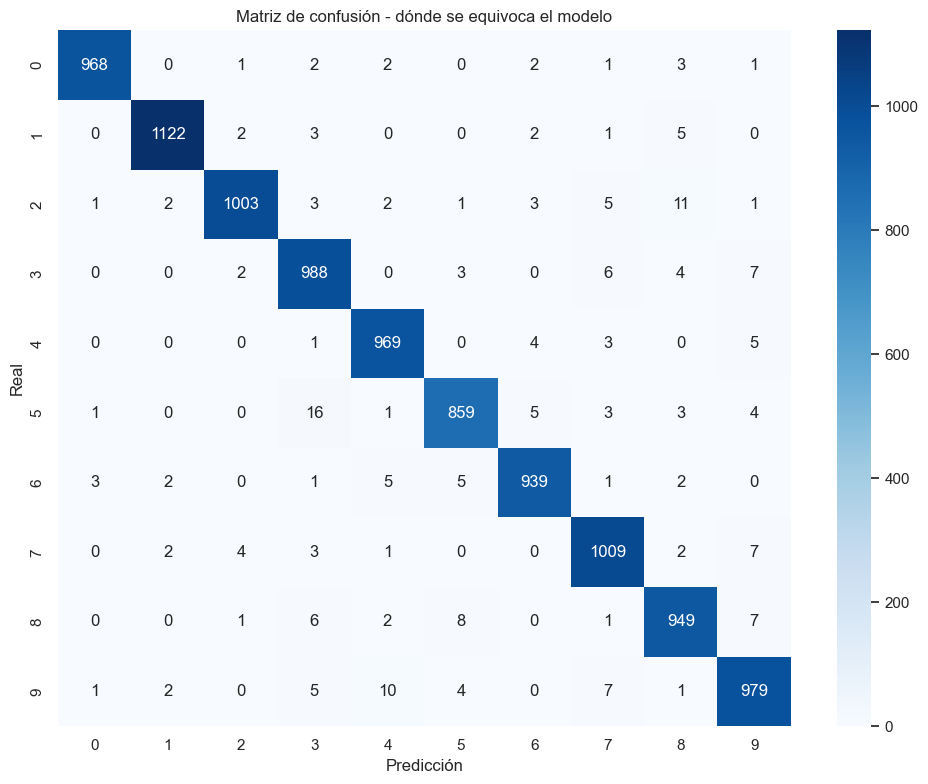

In [12]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

test_images, test_labels = next(iter(test_data))
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_labels.numpy(), predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — where the model makes mistakes")
plt.tight_layout()
plt.show()

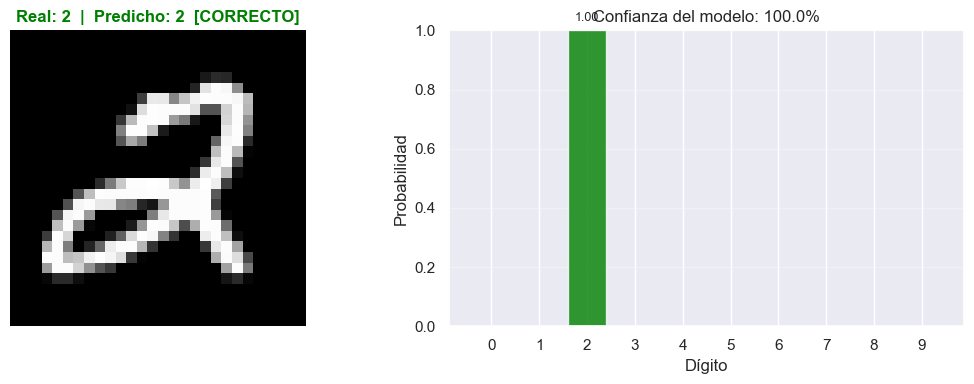

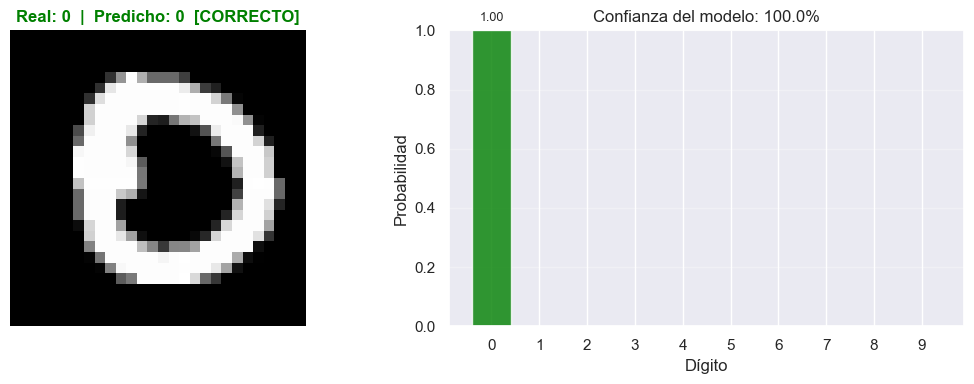

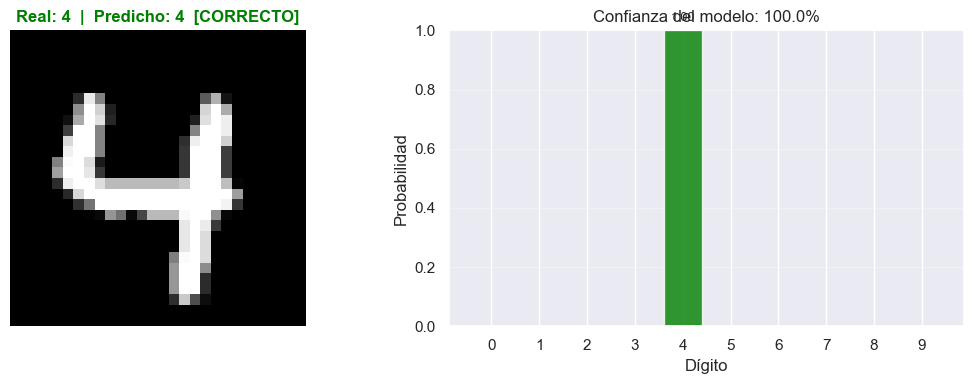

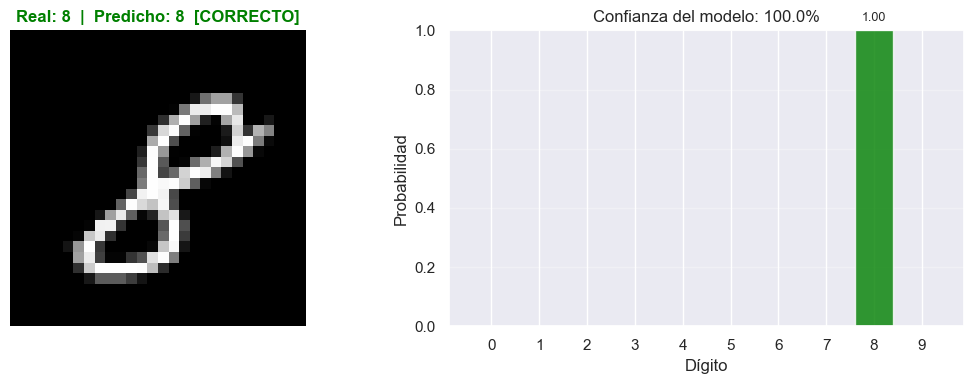

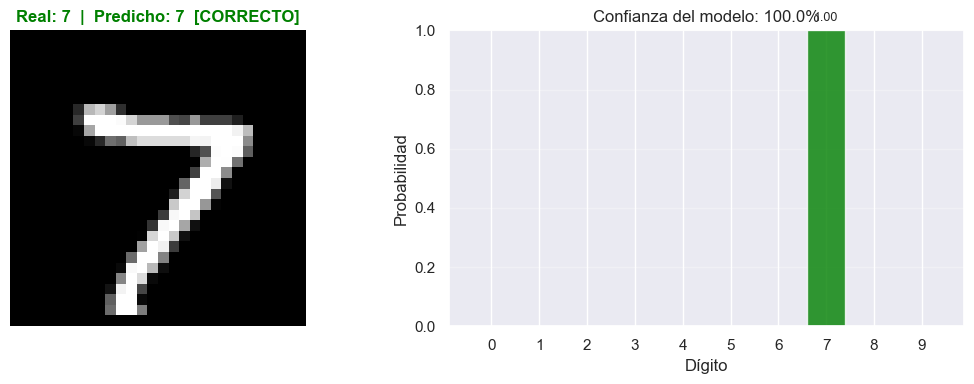

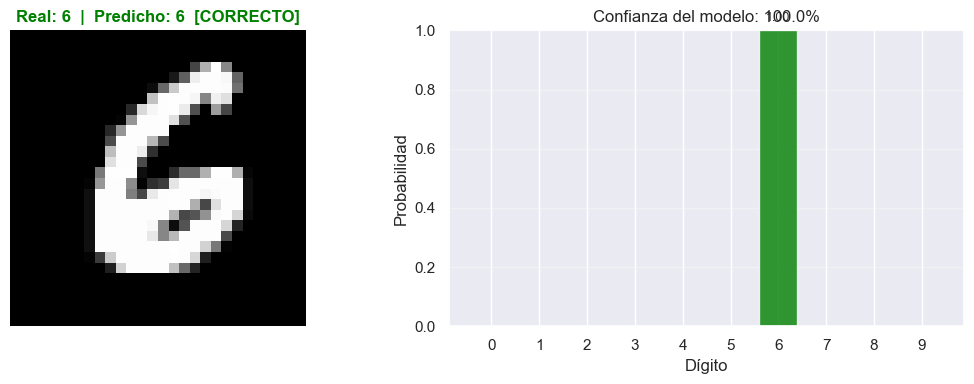

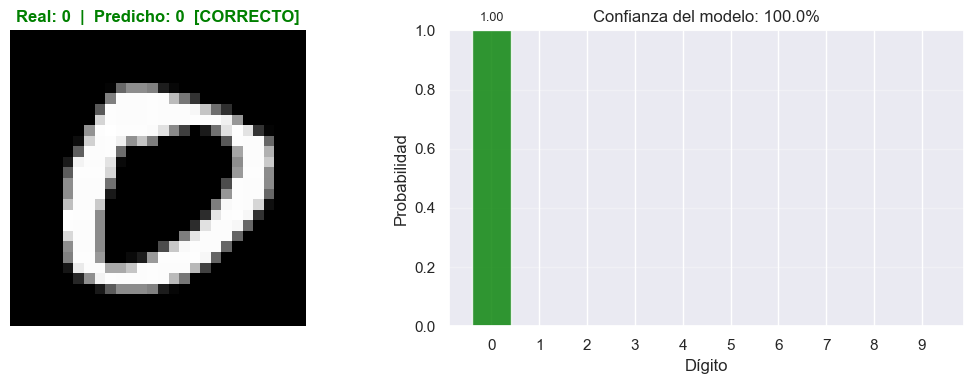

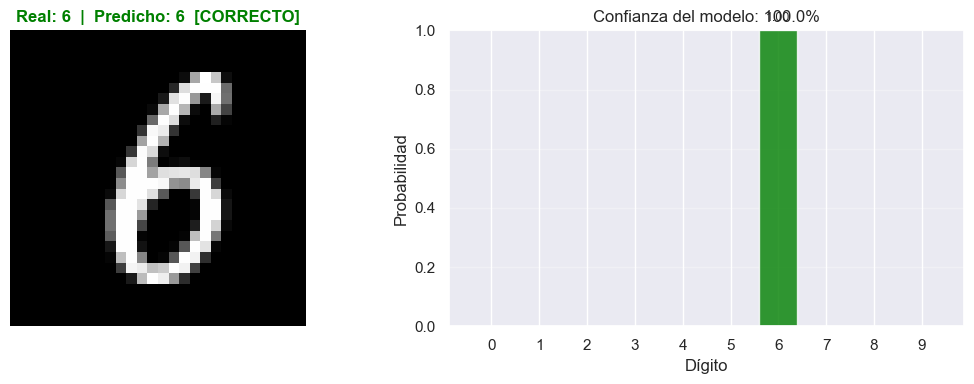

In [13]:
def visualize_prediction(model, image, true_label):
    pred = model.predict(image[np.newaxis, ...], verbose=0)[0]
    predicted = np.argmax(pred)
    is_correct = predicted == true_label

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.imshow(image.numpy().squeeze(), cmap="gray")
    color = "green" if is_correct else "red"
    status = "CORRECT" if is_correct else "WRONG"
    ax1.set_title(f"True: {true_label}  |  Predicted: {predicted}  [{status}]",
                  color=color, fontsize=12, fontweight="bold")
    ax1.axis("off")

    colors = ["green" if i == true_label else
              "red" if i == predicted else
              "steelblue" for i in range(10)]
    bars = ax2.bar(range(10), pred, color=colors, alpha=0.8, edgecolor="white")
    ax2.set_xticks(range(10))
    ax2.set_xlabel("Digit")
    ax2.set_ylabel("Probability")
    ax2.set_title(f"Model confidence: {pred[predicted]*100:.1f}%")
    ax2.set_ylim(0, 1)
    ax2.grid(True, axis="y", alpha=0.3)

    for bar, val in zip(bars, pred):
        if val > 0.05:
            ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

# run 8 sample predictions
for i in range(8):
    visualize_prediction(model, test_images[i], test_labels[i].numpy())

In [14]:
model.save("mnist_model.keras")
print("Model saved")

Modelo guardado
